# SETUP
Importante comprobar versión de CUDA si se va a usar GPU. Si no, pip install dgl.

In [1]:
!python --version

Python 3.11.11


In [2]:
%%capture
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 torchdata==0.9.0
!conda install -c dglteam/label/th24_cu121 dgl -y
!pip install deepchem
!pip install dgllife
!pip install optuna

In [3]:
import numpy as np
import pandas as pd
import torch
import dgl
import dgllife
import deepchem as dc

print("Numpy Version : ", np.__version__)
print("Pandas Version : ", pd.__version__)
print("Pytorch Version : ", torch.__version__)
print("Dgl Version : ", dgl.__version__)
print("Dgllife Version : ", dgllife.__version__)
print("DeepChem Version : ", dc.__version__)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/home/alfon/.pyenv/versions/miniconda3-latest/envs/bioDL/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules 

Numpy Version :  2.4.3
Pandas Version :  3.0.1
Pytorch Version :  2.4.0+cu121
Dgl Version :  2.4.0+cu121
Dgllife Version :  0.3.2
DeepChem Version :  2.8.0


### Conversión de moléculas a grafos para Graph Neural Network

In [4]:
# El featurizer para GNN debe capturar la estructura del grafo
featurizer = dc.feat.MolGraphConvFeaturizer()

# Cargamos el dataset (suponiendo que tienes un CSV con 'smiles' y 'target')
loader = dc.data.CSVLoader(tasks=["pchembl_value"], 
                           feature_field="canonical_smiles", 
                           featurizer=featurizer)
dataset = loader.create_dataset("../data/CHEMBL1075104_nonredundant.csv")

### Scaffold Splitting

In [5]:
# Definimos el splitter
splitter = dc.splits.ScaffoldSplitter()

# Dividimos el dataset (80% tren, 10% validación, 10% test)
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, 
    frac_train=0.8, 
    frac_valid=0.1, 
    frac_test=0.1
)

print(f"Entrenamiento: {len(train_dataset)} moléculas")
print(f"Prueba (Nuevos Scaffolds): {len(test_dataset)} moléculas")

Entrenamiento: 2736 moléculas
Prueba (Nuevos Scaffolds): 343 moléculas


### Optuna Study (Encontrar mejores hiperparámetros)

In [11]:
import optuna
import os
import torch
import deepchem as dc

# 1. Definimos el nombre del archivo de la base de datos
db_file = "test.db"
storage_name = f"sqlite:///../studies/{db_file}"

def objective(trial):
    # Definimos rangos más estrictos para evitar el overfitting (0.93 vs 0.42)
    n_layers = trial.suggest_int('n_layers', 2, 3) # Menos capas = más generalización
    n_heads = trial.suggest_categorical('n_heads', [4, 8, 12])
    dropout = trial.suggest_float('dropout', 0.35, 0.55) # Forzamos dropout alto
    lr = trial.suggest_float('lr', 5e-5, 1e-3, log=True)
    
    layers = [16] * n_layers
    
    model = dc.models.GATModel(
        n_tasks=1,
        graph_attention_layers=layers,
        n_attention_heads=n_heads,
        dropout=dropout,
        learning_rate=lr,
        mode='regression',
    )
    
    # Entrenamiento controlado
    model.fit(train_dataset, nb_epoch=100)
    
    metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
    valid_score = model.evaluate(valid_dataset, [metric])['pearson_r2_score']
    
    return valid_score

# 2. Creamos o cargamos el estudio persistente
study = optuna.create_study(
    study_name="lrrk2_optimization", 
    storage=storage_name, 
    direction="maximize",
    load_if_exists=True
)

# 3. Lanzamos la optimización
study.optimize(objective, n_trials=1)

print(f"Estudio finalizado y guardado en {db_file}")

[I 2026-03-26 17:13:46,681] Using an existing study with name 'lrrk2_optimization' instead of creating a new one.
[I 2026-03-26 17:16:40,381] Trial 1 finished with value: 0.2972044051694899 and parameters: {'n_layers': 2, 'n_heads': 4, 'dropout': 0.3679471368991453, 'lr': 6.659306823983225e-05}. Best is trial 1 with value: 0.2972044051694899.


Estudio finalizado y guardado en test.db


### Entrenamiento profundo del modelo seleccionado: (500 epochs)

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import deepchem as dc

# 1. Configuración del modelo con tus mejores parámetros de Optuna
model_dir = "mejor_modelo_lrrk2"
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
rmse_metric = dc.metrics.Metric(dc.metrics.rms_score)

final_model = dc.models.GATModel(
    n_tasks=1,
    graph_attention_layers=[16] * study.best_params['n_layers'],
    n_attention_heads=study.best_params['n_heads'],
    dropout=study.best_params['dropout'],
    learning_rate=study.best_params['lr'],
    model_dir=model_dir,
)

# 2. El Callback: Se encarga de guardar el MEJOR modelo en disco automáticamente
# Evalúa cada 10 épocas y si mejora el R2, guarda un checkpoint.
callback = dc.models.ValidationCallback(
    valid_dataset, 
    interval=10, 
    metrics=[metric],
    save_dir=model_dir
)

# 3. Listas para la gráfica (Manual)
train_errors = []
valid_errors = callback.val
epochs = 50

final_model.fit(train_dataset, nb_epoch=epochs, callbacks=callback, all_losses=train_errors)

# 4. EL PASO MÁGICO: Restaurar el mejor modelo encontrado por el callback
print("\nRestaurando el mejor modelo guardado durante el entrenamiento...")
final_model.restore() 

# 5. Evaluación final (Ya con el modelo optimizado cargado)
final_r2_test = final_model.evaluate(test_dataset, [metric])['pearson_r2_score']
print(f"--- RESULTADO FINAL EN TEST (Modelo Restaurado): {final_r2_test:.4f} ---")

AttributeError: 'ValidationCallback' object has no attribute 'valid_scores'

### Curva de Aprendizaje

AttributeError: 'ValidationCallback' object has no attribute 'valid_score'

ValueError: x and y must have same first dimension, but have shapes (5,) and (2,)

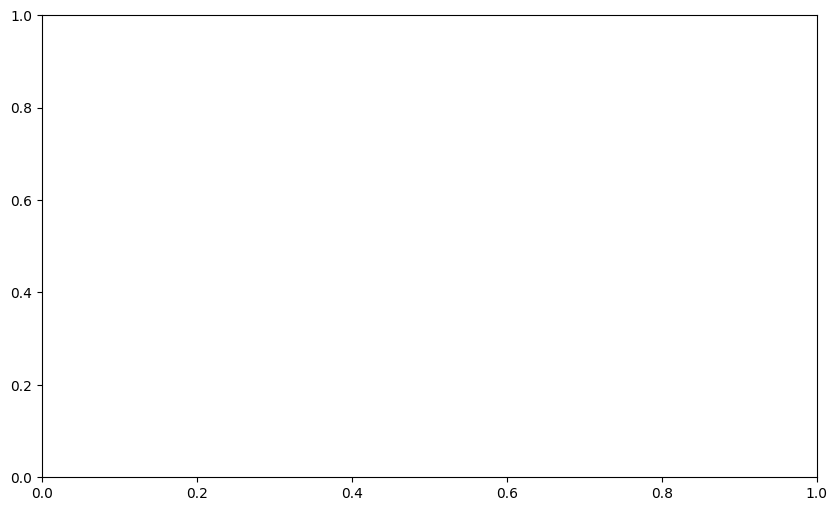

In [17]:
plt.figure(figsize=(10, 6))
x_axis = range(0, epochs, 10)

plt.plot(x_axis, train_errors, label='Error Entrenamiento (RMSE)', color='#4A90E2', lw=2)
plt.plot(x_axis, valid_errors, label='Error Validación (RMSE)', color='#7ED321', lw=2)

# Marcamos el punto donde el Callback probablemente hizo el mejor guardado
idx_min_val = np.argmin(valid_errors)
plt.axvline(x=x_axis[idx_min_val], color='red', linestyle='--', alpha=0.6, label='Punto de Restore()')

plt.title('Curva de Aprendizaje: Optimización LRRK2')
plt.xlabel('Épocas (Complejidad)')
plt.ylabel('RMSE (Error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Resultados del modelo

In [ ]:
import numpy as np

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Evaluamos el modelo
train_score = final_model.evaluate(train_dataset, [metric])
valid_score = final_model.evaluate(valid_dataset, [metric])
test_score = final_model.evaluate(test_dataset, [metric])

print(f"R^2 en Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R^2 en Validación: {valid_score['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score['pearson_r2_score']:.3f}")

In [ ]:
# Predecimos
test_pred = final_model.predict(test_dataset)
test_true = test_dataset.y

plt.figure(figsize=(7, 7))
plt.scatter(test_true, test_pred, alpha=0.5, c='teal', edgecolors='k')
plt.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
plt.xlabel('pChEMBL Real (Experimental)')
plt.ylabel('pChEMBL Predicho (GAT Model)')
plt.title(f'Validación Externa (Test Set)\n$R^2$ Final: {test_score:.3f}')
plt.tight_layout()
plt.show()

### Guardar modelo final

In [9]:
# Crea una carpeta específica para la entrega final
ruta_final = "../models/GATModelLRRK2"
modelo_cargado.save_checkpoint(max_checkpoints_to_keep=5, model_dir=ruta_final)

print(f"Modelo exportado correctamente en: {ruta_final}")

Modelo exportado correctamente en: ../models/GATModelLRRK2


### Cargar modelo final

In [31]:
import optuna
import deepchem as dc

# 1. Cargamos el estudio desde el archivo .db
storage_name = "sqlite:///../studies/CHEMBL1075104_study_GAT.db"
study = optuna.load_study(study_name="CHEMBL1075104_optimization", storage=storage_name)

# 2. Defines la arquitectura (DEBE ser igual a la de Optuna)
modelo_cargado = dc.models.GATModel(
    n_tasks=1,
    graph_attention_layers=[16] * study.best_params['n_layers'],
    n_attention_heads=study.best_params['n_heads'],
    # ... resto de parámetros ...
    model_dir="../models/CHEMBL1075104_gat/" 
)

# 3. Restauras los pesos
modelo_cargado.restore()

# 4. ¡A predecir!
# pchembl_predicha = modelo_cargado.predict(nuevas_moleculas_dataset)

In [35]:
import numpy as np

final_model = modelo_cargado

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)

# 2. Evaluamos el modelo
train_score = final_model.evaluate(train_dataset, [metric])
valid_score = final_model.evaluate(valid_dataset, [metric])
test_score = final_model.evaluate(test_dataset, [metric])

print(f"R^2 en Entrenamiento: {train_score['pearson_r2_score']:.3f}")
print(f"R^2 en Validación: {valid_score['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score['pearson_r2_score']:.3f}")

R^2 en Entrenamiento: 0.492
R^2 en Validación: 0.262
R^2 en Test (Moléculas nuevas): 0.282


In [27]:
import optuna
# 1. Cargamos el estudio "sucio"
old_study = optuna.load_study(study_name="lrrk2_optimization", storage="sqlite:///../studies/lrrk2_study_GAT.db")

# 2. Creamos un estudio nuevo (en un archivo nuevo)
new_storage = "sqlite:///../studies/CHEMBL1075104_study_GAT.db"
new_study = optuna.create_study(study_name="CHEMBL1075104_optimization", storage=new_storage, direction="maximize")

# 3. Copiamos todos los trials EXCEPTO el que te dio error (ej. el 21)
for trial in old_study.trials:
    new_study.add_trial(trial)

print("Estudio clonado sin el error. ¡Usa 'optuna_lrrk2_LIMPIO.db' a partir de ahora!")

[I 2026-03-26 17:47:34,955] A new study created in RDB with name: CHEMBL1075104_optimization


Estudio clonado sin el error. ¡Usa 'optuna_lrrk2_LIMPIO.db' a partir de ahora!
